# Exploratory Data Analysis — NASA C-MAPSS Turbofan Engine Degradation (FD001)

This notebook explores the raw sensor telemetry before any modeling decisions
are made: target distribution, per-engine degradation trends, and sensor
correlation/variance, which directly informed the feature selection and RUL
clipping choices used in `src/data.py` and `src/train.py`.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt
from src.data import load_cmapss, build_test_labels, SENSOR_COLS, CONSTANT_SENSORS

ds = load_cmapss('../data', 'FD001')
train, test, rul = ds.train, ds.test, ds.test_rul
print('Train shape:', train.shape)
print('Test shape:', test.shape)
print('Engines in train:', train.unit_number.nunique(), '| Engines in test:', test.unit_number.nunique())
train.head()

Train shape: (20631, 27)
Test shape: (13096, 26)
Engines in train: 100 | Engines in test: 100


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,125


## Engine lifetime distribution
How many cycles does each engine run before failure in the training set?

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_in_cycles, dtype: float64


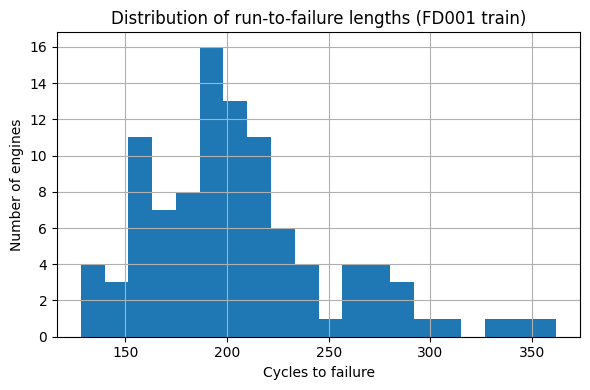

In [2]:
lifetimes = train.groupby('unit_number')['time_in_cycles'].max()
print(lifetimes.describe())
plt.figure(figsize=(6,4))
lifetimes.hist(bins=20)
plt.xlabel('Cycles to failure'); plt.ylabel('Number of engines')
plt.title('Distribution of run-to-failure lengths (FD001 train)')
plt.tight_layout(); plt.show()

## RUL target after clipping
Early-life RUL is not learnable from sensors alone (the engine looks identical whether it will fail in 50 or 300 cycles), so the target is capped at 125 cycles, producing a piecewise-linear degradation curve.

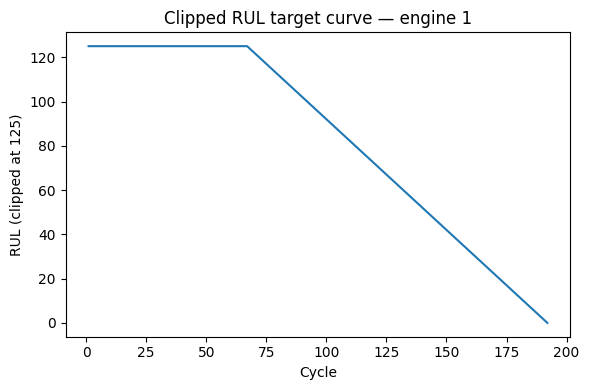

In [3]:
unit = train[train.unit_number == 1]
plt.figure(figsize=(6,4))
plt.plot(unit.time_in_cycles, unit.RUL)
plt.xlabel('Cycle'); plt.ylabel('RUL (clipped at 125)')
plt.title('Clipped RUL target curve — engine 1')
plt.tight_layout(); plt.show()

## Sensor degradation trends
A handful of sensors show a clear monotonic drift as the engine approaches failure — these are exactly the ones the trained models weight most heavily (see the SHAP summary in `assets/shap_summary.png`).

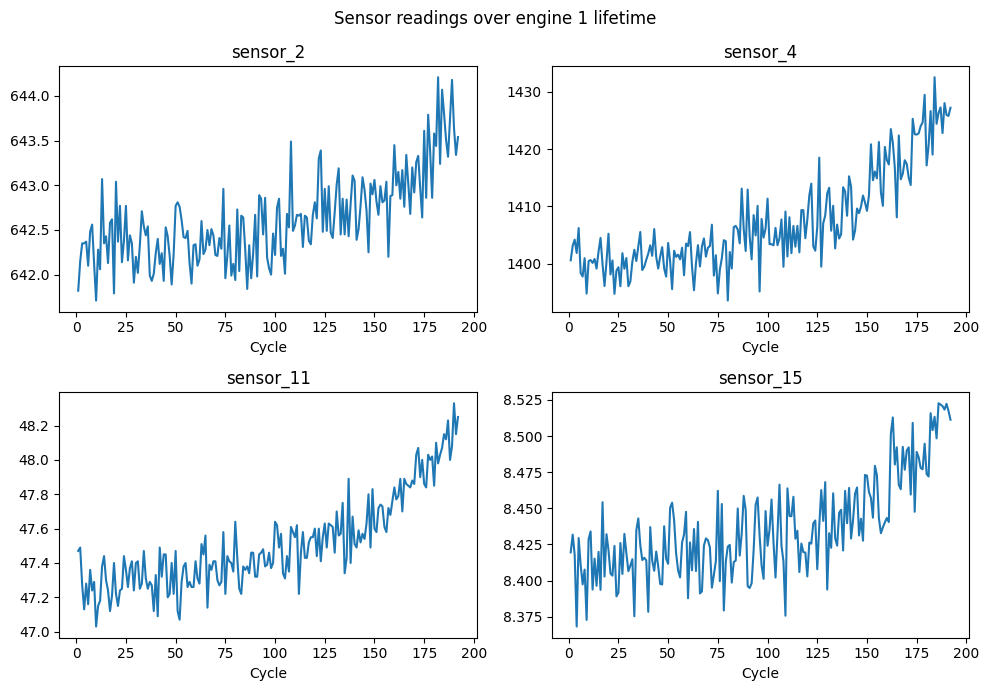

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, col in zip(axes.flat, ['sensor_2', 'sensor_4', 'sensor_11', 'sensor_15']):
    ax.plot(unit.time_in_cycles, unit[col])
    ax.set_title(col)
    ax.set_xlabel('Cycle')
plt.suptitle('Sensor readings over engine 1 lifetime')
plt.tight_layout(); plt.show()

## Constant / near-zero-variance sensors
These sensors are flat across the whole FD001 training set (a side effect of the simulation's single operating condition) and carry no signal for RUL — they are dropped in `src/data.py`.

In [5]:
variances = train[SENSOR_COLS].var().sort_values()
print(variances)
print('\nDropped as constant:', CONSTANT_SENSORS)

sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.203765e-35
sensor_5     2.840037e-29
sensor_6     1.929279e-06
sensor_15    1.406628e-03
sensor_8     5.038938e-03
sensor_13    5.172330e-03
sensor_21    1.171825e-02
sensor_20    3.266927e-02
sensor_11    7.133568e-02
sensor_2     2.500533e-01
sensor_12    5.439850e-01
sensor_7     7.833883e-01
sensor_17    2.398667e+00
sensor_3     3.759099e+01
sensor_4     8.101089e+01
sensor_14    3.639005e+02
sensor_9     4.876536e+02
dtype: float64

Dropped as constant: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


## Sensor correlation
Several sensors are highly correlated with each other, which is why tree-based models (robust to collinearity) outperform plain linear regression here.

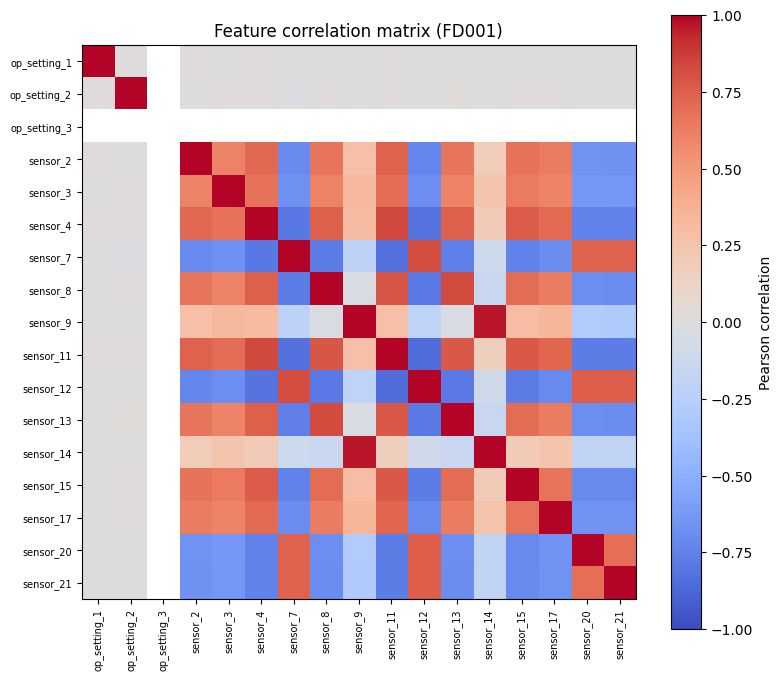

In [6]:
import numpy as np
feature_cols = ds.feature_cols
corr = train[feature_cols].corr()
plt.figure(figsize=(8,7))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(feature_cols)), feature_cols, rotation=90, fontsize=7)
plt.yticks(range(len(feature_cols)), feature_cols, fontsize=7)
plt.colorbar(label='Pearson correlation')
plt.title('Feature correlation matrix (FD001)')
plt.tight_layout(); plt.show()